# P값이 0.049면 출시해도 되죠?

A/B 테스트 챕터의 실습 노트북입니다.

이 실습은 A/B 테스트를 처음부터 끝까지 진행하는 방법을 다루지 않습니다. 본문에서 살펴본,
**A/B 테스트 결과가 우리를 속이는 대표적인 함정들을 직접 눈으로 확인해 보는** 실습입니다.
그러니 전체적인 흐름을 이해했다면, 코드에 등장하는 통계적인 디테일을 모두 이해할 필요는 없습니다.

- **실습 1.** 동전 던지기 — 우연은 생각보다 크게 출렁입니다
- **실습 2.** 며칠 돌려야 하나요 — 표본 크기 계산기의 원리
- **실습 3.** 무작위로 나눴는데 왜 안 공평하죠 — 여행자보험 사례
- **실습 4.** 3일째, 대시보드에 p = 0.04 — 지금 멈추면 안 되나요?

이 챕터는 **별도의 데이터 파일이 없습니다.** '진짜 전환율'을 코드에 정해 두고 실험을 통째로
시뮬레이션하기 때문에, 정답을 아는 상태에서 실험이 어떻게 우리를 속이는지를 관찰해 보겠습니다.

## 0. 준비

In [27]:
# 의존성 설치 (이미 설치돼 있으면 빠르게 넘어갑니다)
# %pip 매직은 현재 커널 환경에 설치하므로 PATH 문제 없이 동작합니다.
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)   # 재현성

## 실습 1. 동전 던지기 — 우연은 생각보다 크게 출렁입니다

동전을 던졌을 때 앞면이 나올 확률은 50%입니다. 그렇다고 100번 던지면 정확히 50번 나올까요?
47번 나오기도 하고, 52번 나오기도 하죠. 전환율도 똑같습니다.

진짜 전환율이 **정확히 4%인 화면**을 1만 명에게 보여주는 실험을 다섯 번 반복해 보겠습니다.
화면은 매번 완전히 같습니다. 그런데도 관측되는 전환율은 꽤 달라질 수 있습니다.

In [29]:
np.random.seed(42)

# 진짜 전환율이 4%로 '고정'된 화면을 10,000명에게 보여주는 일을 다섯 번 반복합니다
for i in range(5):
    conversions = np.random.binomial(10_000, 0.04)   # 10,000명 중 몇 명이 결제했나
    print(f"{i + 1}번째 실험: 10,000명 중 {conversions}명 결제 → 관측된 전환율 {conversions / 10_000:.2%}")

1번째 실험: 10,000명 중 384명 결제 → 관측된 전환율 3.84%
2번째 실험: 10,000명 중 403명 결제 → 관측된 전환율 4.03%
3번째 실험: 10,000명 중 370명 결제 → 관측된 전환율 3.70%
4번째 실험: 10,000명 중 407명 결제 → 관측된 전환율 4.07%
5번째 실험: 10,000명 중 364명 결제 → 관측된 전환율 3.64%


## 실습 2. 며칠 돌려야 하나요 — 표본 크기 계산기의 원리

실험 설계 회의에서 반드시 나오는 질문이 있죠. "그래서 이거 며칠 돌리면 되나요?"

본문에서 소개했듯, 이 답은 웹의 표본 크기 계산기(Evan Miller의 Sample Size Calculator 등)에
숫자 몇 개만 넣으면 바로 얻을 수 있습니다. 실무에서는 그걸 쓰시면 됩니다. 여기서는 그 계산기가
**어떤 원리로 답을 주는지 감을 잡기 위해**, 같은 계산을 코드로 직접 돌려보겠습니다.

본문의 예시 그대로, 결제 화면 도달 유저가 하루 1,000명(집단당 500명)이고 전환율이 4%인
서비스로 계산해 보겠습니다.

(참고: 앞으로 나올 '+1%p'의 **%p(퍼센트포인트)**는 전환율 4%가 5%가 되는, 퍼센트 숫자
자체의 변화를 뜻합니다. "4%의 1%"라는 뜻이 아닙니다.)

감지하고 싶은 효과가 작아질수록, 실험은 얼마나 길어질까요?

전환율 +3.0%p 를 감지하려면 → 집단당 903명, 약 2일
전환율 +2.0%p 를 감지하려면 → 집단당 1,861명, 약 4일
전환율 +1.0%p 를 감지하려면 → 집단당 6,744명, 약 14일
전환율 +0.5%p 를 감지하려면 → 집단당 25,552명, 약 52일

감지하려는 효과를 +2%p → +1%p로 절반으로 줄이면, 필요한 표본은 약 3.6배가 됩니다


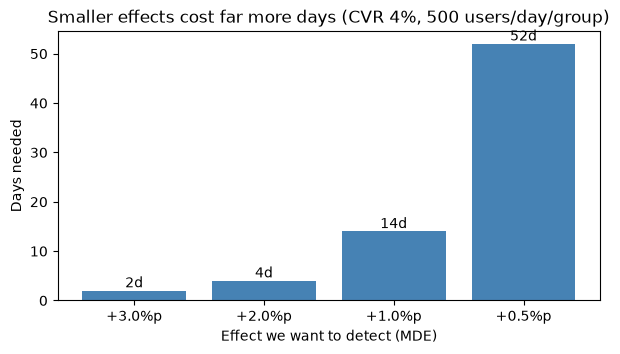

In [30]:
# ── 여기 숫자만 바꿔서 다시 실행해 보세요 ──────────────────────
BASE_CVR = 0.04        # 현재 전환율 4%
DAILY_PER_GROUP = 500  # 하루 1,000명이 A/B 반반으로 나뉘어 집단당 500명
# ──────────────────────────────────────────────────────


def required_sample(base_cvr, mde):
    # 웹의 표본 크기 계산기가 쓰는 공식을 그대로 옮긴 함수입니다. 내부 수식까지 이해할
    # 필요는 없습니다 — '효과가 우연의 출렁임보다 확실히 커 보이려면 집단당 몇 명이
    # 필요한가'를 계산한다는 것만 기억하면 됩니다.
    # (7.85는 관례적 기준인 '유의수준 5%·검정력 80%'를 숫자 하나로 요약한 상수입니다)
    p2 = base_cvr + mde
    variance = base_cvr * (1 - base_cvr) + p2 * (1 - p2)
    return int(np.ceil(7.85 * variance / mde ** 2))


print("감지하고 싶은 효과가 작아질수록, 실험은 얼마나 길어질까요?\n")
days_needed = {}
for mde in [0.03, 0.02, 0.01, 0.005]:
    n = required_sample(BASE_CVR, mde)
    days_needed[mde] = int(np.ceil(n / DAILY_PER_GROUP))
    print(f"전환율 +{mde * 100:.1f}%p 를 감지하려면 → 집단당 {n:,}명, 약 {days_needed[mde]}일")

ratio = required_sample(BASE_CVR, 0.01) / required_sample(BASE_CVR, 0.02)
print(f"\n감지하려는 효과를 +2%p → +1%p로 절반으로 줄이면, 필요한 표본은 약 {ratio:.1f}배가 됩니다")

plt.figure(figsize=(7, 3.5))
labels = [f"+{m * 100:.1f}%p" for m in days_needed]
plt.bar(labels, list(days_needed.values()), color="steelblue")
for x, d in zip(labels, days_needed.values()):
    plt.text(x, d, f"{d}d", ha="center", va="bottom")
plt.xlabel("Effect we want to detect (MDE)")
plt.ylabel("Days needed")
plt.title("Smaller effects cost far more days (CVR 4%, 500 users/day/group)")
plt.show()

## 실습 3. 무작위로 나눴는데 왜 안 공평하죠 — 여행자보험 사례

본문 1장의 사건을 재현해 보겠습니다. 여행 서비스가 여행자보험 배너 A/B 테스트를 했고,
B안이 이겼습니다. 그런데 결과를 검증하던 분석가가 이상한 점을 발견합니다 — B그룹에
**'여행이 임박한' 유저가 우연히 더 많이** 들어가 있었던 겁니다. 여행자보험은 여행 직전에
사는 상품이니, 배너가 아니라 이 쏠림이 결과를 만들었을 수 있습니다.

정말 그럴 수 있을까요? 시뮬레이션에는 **배너 효과를 0으로** 심어 두겠습니다. 그런데도
B가 이긴 것처럼 보인다면, 범인은 배너가 아니라 쏠림인 것이죠.

A그룹 전환율 1.88%  vs  B그룹 전환율 2.04%
→ 배너는 아무 차이가 없는데도, B가 +8% 이긴 것처럼 보입니다

이 실험을 10,000번 반복해서 시뮬레이션하면 그중 959번, 약 10%에서 ±8% 이상의 가짜 효과가 보입니다.


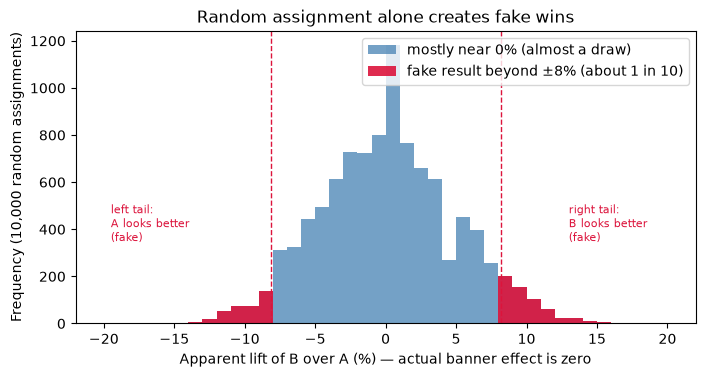

In [31]:
np.random.seed(42)

# ── 사건 현장: 숫자를 바꿔가며 실험해 보세요 ──────────────────
N_TOTAL = 10_000     # 실험 참가자 1만 명 (A/B 5,000명씩)
N_TRAVEL = 400       # 그중 '여행 임박' 유저는 400명뿐 (4%)
CVR_TRAVEL = 0.25    # 여행 임박 유저는 4명 중 1명꼴로 보험 가입
CVR_OTHER = 0.01     # 나머지 유저는 100명 중 1명꼴
# (두 그룹의 배너 효과 차이는 0 — 어느 쪽도 이길 이유가 없습니다)
# ──────────────────────────────────────────────────────

GROUP = N_TOTAL // 2


def group_cvr(travel_in_group):
    # 집단(5,000명)에 여행 임박 유저가 몇 명 섞였는지에 따라 그 집단의 전환율이 정해집니다
    return (travel_in_group * CVR_TRAVEL + (GROUP - travel_in_group) * CVR_OTHER) / GROUP


# 본문의 사건: 여행 임박 유저 400명이 우연히 184명 : 216명으로 쏠린 경우
print(f"A그룹 전환율 {group_cvr(184):.2%}  vs  B그룹 전환율 {group_cvr(216):.2%}")
print(f"→ 배너는 아무 차이가 없는데도, B가 +{group_cvr(216) / group_cvr(184) - 1:.0%} 이긴 것처럼 보입니다\n")

# 이런 '가짜 승부', 얼마나 자주 날까요? 무작위 배정을 10,000번 반복해서 직접 세어 봅니다
lifts = []
for _ in range(10_000):
    # 1만 명을 잘 섞어 반반으로 나눴을 때, A그룹에 들어가는 여행 임박 유저 수
    travel_in_a = np.random.hypergeometric(N_TRAVEL, N_TOTAL - N_TRAVEL, GROUP)
    # 그 쏠림이 만들어내는 '겉보기 상승률' — B그룹이 A그룹보다 몇 % 이긴 것처럼 보이나
    lifts.append(group_cvr(N_TRAVEL - travel_in_a) / group_cvr(travel_in_a) - 1)
lifts = np.array(lifts) * 100   # % 단위

case = (group_cvr(216) / group_cvr(184) - 1) * 100          # 본문 사례의 겉보기 상승률 (+8.2%)
fake_wins = np.mean(np.abs(lifts) >= case - 1e-9)           # 본문 사례만큼 벌어진 '가짜 승부' 비율
print(f"이 실험을 10,000번 반복해서 시뮬레이션하면 그중 {int(fake_wins * 10_000):,}번, 약 {fake_wins:.0%}에서 ±{case:.0f}% 이상의 가짜 효과가 보입니다.")

bins = np.arange(-20, 21)                     # 1% 폭 구간
fakes = lifts[np.abs(lifts) >= case - 1e-9]   # 빨간 점선 바깥 — 본문 사례 이상으로 벌어진 배정

plt.figure(figsize=(8, 3.8))
plt.hist(lifts, bins=bins, color="steelblue", alpha=0.75, label="mostly near 0% (almost a draw)")
plt.hist(fakes, bins=bins, color="crimson", alpha=0.9, label=f"fake result beyond ±{case:.0f}% (about 1 in 10)")
plt.axvline(case, color="crimson", ls="--", lw=1)
plt.axvline(-case, color="crimson", ls="--", lw=1)
plt.text(-19.5, 350, "left tail:\nA looks better\n(fake)", fontsize=8, color="crimson")
plt.text(13.0, 350, "right tail:\nB looks better\n(fake)", fontsize=8, color="crimson")
plt.xlabel("Apparent lift of B over A (%) — actual banner effect is zero")
plt.ylabel("Frequency (10,000 random assignments)")
plt.title("Random assignment alone creates fake wins")
plt.legend()
plt.show()

위 그래프에서 빨간 색으로 표시된 영역은, 배너 효과가 0인데도 본문 사례만큼(±8%) 차이가 벌어져 보인 실험들입니다.
배너 효과가 전혀 없다고 가정하고 시뮬레이션 했음에도 불구하고 
균등하지 않은 분포 때문에 10% 가까운 시도에서 잘못된 결과가 나오는 셈이죠.

무작위 배정은 '평균적으로' 공평할 뿐(분포의 중심이 0%), 매번 균형을 보장하지는 않습니다.
특히 이 사례처럼 **수는 적은데 전환율은 유난히 높은** 유형이 있을 때 이 문제가 커집니다.
400명 중 몇십 명만 쏠려도 전체 결과가 흔들리니까요.

이를 막기 위해서는 본문에서 소개한 **층화 배정**과 같은 방법을 고려할 수 있습니다. 

층화 배정 → A그룹 1.96%  vs  B그룹 1.96%  (겉보기 차이가 사라졌습니다)


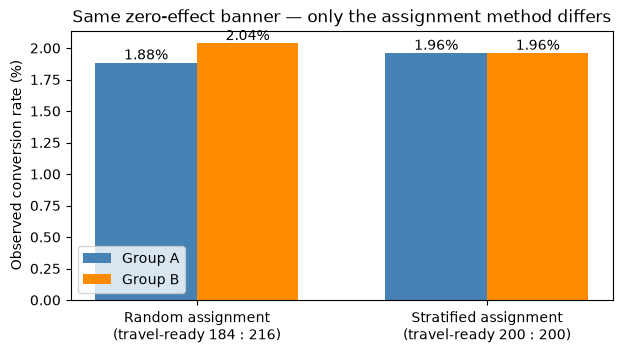

배정 점검: 설계 5,000:5,000 ≠ 실제 5,000:4,500 이라면 → 결과 해석을 멈추고 원인부터 (SRM)


In [32]:
# 층화 배정: 여행 임박 유저 400명을 먼저 200:200으로 나눈 뒤 나머지를 배정합니다
print(f"층화 배정 → A그룹 {group_cvr(200):.2%}  vs  B그룹 {group_cvr(200):.2%}  (겉보기 차이가 사라졌습니다)")

# 같은 실험을 배정 방식만 바꿔서 나란히 놓고 비교해 봅니다
x, width = np.arange(2), 0.35
cvr_a = [group_cvr(184) * 100, group_cvr(200) * 100]   # 무작위(쏠림) vs 층화
cvr_b = [group_cvr(216) * 100, group_cvr(200) * 100]

plt.figure(figsize=(7, 3.5))
plt.bar(x - width / 2, cvr_a, width, color="steelblue", label="Group A")
plt.bar(x + width / 2, cvr_b, width, color="darkorange", label="Group B")
for xpos, v in list(zip(x - width / 2, cvr_a)) + list(zip(x + width / 2, cvr_b)):
    plt.text(xpos, v, f"{v:.2f}%", ha="center", va="bottom")
plt.xticks(x, ["Random assignment\n(travel-ready 184 : 216)", "Stratified assignment\n(travel-ready 200 : 200)"])
plt.ylabel("Observed conversion rate (%)")
plt.title("Same zero-effect banner — only the assignment method differs")
plt.legend()
plt.show()

# 덧붙여, 실험이 끝나면 전환율을 보기 전에 '인원수'부터 세어 보세요. 반반으로 설계했는데
# 로그에 5,000 : 4,500으로 남아 있다면 어딘가에서 유저가 새고 있다는 신호(SRM)입니다.
print("배정 점검: 설계 5,000:5,000 ≠ 실제 5,000:4,500 이라면 → 결과 해석을 멈추고 원인부터 (SRM)")

## 실습 4. 3일째, 대시보드에 p = 0.04 — 지금 멈추면 안 되나요?

실험을 시작한 지 3일째 되는 날, 대시보드에 p = 0.04가 찍혀 있습니다. "벌써 유의하네요.
2주까지 기다릴 필요 없이 지금 끝내고 출시하면 안 되나요?" 트래픽은 아깝고 결과는 좋아 보이니,
굉장히 합리적인 제안처럼 들리죠. 이 의사결정이 왜 위험한지를 데이터로 확인해 보겠습니다.

A안과 A안을 비교하는, 즉 두 집단의 진짜 전환율이 똑같이 4%인 실험을 만들어서 5000번의 시뮬레이션을 돌려 보겠습니다.
전환율 차이가 없으니, 유의한 결과는 약속한 오류율인 5% 수준으로만 나와야 정상이겠죠.
하지만 매일 p값을 들여다보다가, p값이 0.05 아래로 떨어지는 순간 실험을 종료해버리면, 훨씬 많은 비율의 유의한 실험 결과를 '만들어 낼 수 있습니다'.
전체적으로는 유의하지 않은 결과임에도 불구하고 그 순간에는 유의한 것처럼 보이는 순간이 생기게 되기 때문입니다.

약속대로 14일 뒤 한 번만 확인 → 5,000번 중 5.5%가 '유의' (약속한 5% 근처)
매일 보다가 유의하면 바로 종료 → 5,000번 중 22.4%가 '유의' — 전부 가짜 승리입니다


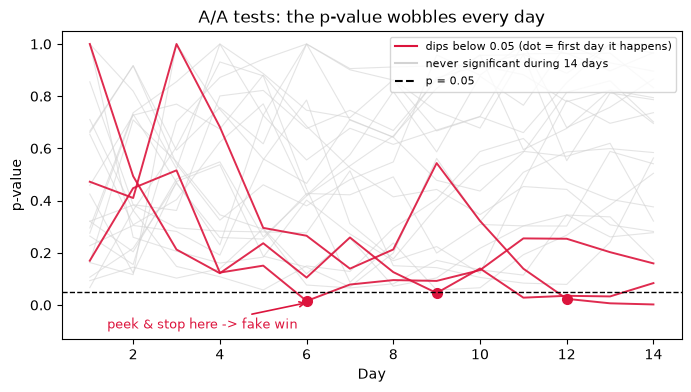

In [33]:
np.random.seed(42)


def p_value(conv_a, conv_b, n_per_group):
    # 두 집단의 누적 전환 수로 p값을 계산합니다 (통계 검정 공식 — 내부는 몰라도 됩니다)
    p_a, p_b = conv_a / n_per_group, conv_b / n_per_group
    pooled = (conv_a + conv_b) / (2 * n_per_group)
    se = np.sqrt(pooled * (1 - pooled) * 2 / n_per_group)
    return 2 * stats.norm.sf(abs(p_b - p_a) / se)


# ── 이길 수 없는 실험 5,000번: A안 vs A안 (둘 다 진짜 전환율 4%) ──
N_SIM, DAYS, CVR = 5_000, 14, 0.04

daily_pvals = []                       # 실험마다 1일차~14일차의 p값을 기록합니다
for _ in range(N_SIM):
    conv_a, conv_b, pvals = 0, 0, []
    for day in range(1, DAYS + 1):
        conv_a += np.random.binomial(DAILY_PER_GROUP, CVR)   # 오늘 A그룹에서 나온 전환 수
        conv_b += np.random.binomial(DAILY_PER_GROUP, CVR)   # 오늘 B그룹(사실은 같은 A안)의 전환 수
        pvals.append(p_value(conv_a, conv_b, DAILY_PER_GROUP * day))
    daily_pvals.append(pvals)
daily_pvals = np.array(daily_pvals)

fixed = np.mean(daily_pvals[:, -1] < 0.05)             # 약속대로 14일 뒤 한 번만 확인
peeking = np.mean((daily_pvals < 0.05).any(axis=1))    # 매일 보다가 유의하면 바로 종료
print(f"약속대로 14일 뒤 한 번만 확인 → 5,000번 중 {fixed:.1%}가 '유의' (약속한 5% 근처)")
print(f"매일 보다가 유의하면 바로 종료 → 5,000번 중 {peeking:.1%}가 '유의' — 전부 가짜 승리입니다")

# p값이 실험 기간 내내 어떻게 출렁이는지, 예시를 골라 그려 봅니다
# 회색 선 = 14일 내내 한 번도 유의해지지 않은 실험 20개
# 빨간 선 = 중간에 p < 0.05 아래로 확실히 내려간 실험 3개 (점 = 처음으로 내려간 날)
days_axis = range(1, DAYS + 1)
gray_idx = [i for i in range(len(daily_pvals)) if not (daily_pvals[i] < 0.05).any()][:20]
red_idx = [i for i in range(len(daily_pvals)) if daily_pvals[i].min() < 0.03][:3]

plt.figure(figsize=(8, 4))
for i in gray_idx:
    plt.plot(days_axis, daily_pvals[i], color="lightgray", alpha=0.6, lw=0.8)
for i in red_idx:
    plt.plot(days_axis, daily_pvals[i], color="crimson", alpha=0.9, lw=1.4)
    first_dip = int(np.argmax(daily_pvals[i] < 0.05))   # 처음으로 0.05 아래로 내려간 날
    plt.plot(first_dip + 1, daily_pvals[i][first_dip], "o", color="crimson", ms=7)

d0 = int(np.argmax(daily_pvals[red_idx[0]] < 0.05))
plt.annotate("peek & stop here -> fake win", xy=(d0 + 1.05, daily_pvals[red_idx[0]][d0] - 0.005),
             xytext=(d0 - 3.6, -0.09), fontsize=9, color="crimson",
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2))
plt.ylim(-0.13, 1.05)
plt.axhline(0.05, color="black", ls="--", lw=1)
plt.plot([], [], color="crimson", label="dips below 0.05 (dot = first day it happens)")
plt.plot([], [], color="lightgray", label="never significant during 14 days")
plt.plot([], [], color="black", ls="--", label="p = 0.05")
plt.xlabel("Day")
plt.ylabel("p-value")
plt.title("A/A tests: the p-value wobbles every day")
plt.legend(loc="upper right", fontsize=8)
plt.show()

위 차트에서의 빨간색 그래프는 실험기간 중 단 하루라도 p값이 0.05 아래로 내려간 적이 있는 실험의 예시입니다.
실제로 전체 기간으로 보면 집단 간 차이가 없는데도, 이처럼 p값이 낮게 나온 순간 실험을 종료해버리면 얼마든지 '가짜 승리'를 만들어 낼 수 있습니다.

## 마무리 — 실험을 믿기 전에 확인할 것

네 개의 실습이 각각 본문 체크리스트의 한 줄씩과 연결됩니다.

- **숫자는 원래 출렁인다** — 차이를 봤다고 곧바로 효과라고 믿지 않기 (실습 1)
- **MDE를 계산했는가** — 우리 트래픽으로 이 효과를 볼 수 있는가? (실습 2)
- **배정은 건강한가** — 결과를 흔들 유저 유형이 쏠리지 않았는가? 인원수는 맞는가? (실습 3)
- **종료 시점을 지켰는가** — 중간에 유의하다고 멈추지 않았는가? (실습 4)

시뮬레이션의 좋은 점은 '정답(효과 0)'을 알고 있다는 것입니다. 현실의 실험에서는 정답을
모르기 때문에, 여기서 본 함정들은 결과가 그럴듯할수록 더 위험합니다. 숫자가 좋아 보일
때일수록 설계 단계의 약속 — 표본 크기, 배정 방식, 종료 시점 — 을 꼼꼼하게 체크해야 한다는 점을 꼭 기억하세요.